# Limpieza y validación de datos

## Proyecto: Accidentalidad y precipitación en Barranquilla

En este notebook se realizará el diagnóstico, limpieza, tratamiento de valores faltantes, detección de duplicados, análisis de valores extremos y validación de los datasets utilizados en el proyecto.

In [1]:
import pandas as pd

In [2]:
RUTA_ACCIDENTES = "../dataset/Accidentalidad_en_Barranquilla_20260830.csv"
RUTA_PRECIPITACION = "../dataset/precipitacion_barranquilla.csv"

df_accidentes = pd.read_csv(RUTA_ACCIDENTES)
df_precipitacion = pd.read_csv(RUTA_PRECIPITACION)

print("Datasets cargados correctamente.")

Datasets cargados correctamente.


In [3]:
print("ACCIDENTES:", df_accidentes.shape)
print("PRECIPITACIÓN:", df_precipitacion.shape)

ACCIDENTES: (28523, 11)
PRECIPITACIÓN: (50000, 12)


## 1. Diagnóstico inicial

Se realiza una revisión inicial de los datos para identificar valores faltantes, registros duplicados y posibles valores fuera de rango.

In [4]:
print("=== ACCIDENTES ===")

print("\nValores faltantes:")
print(df_accidentes.isna().sum()[lambda s: s > 0])

print("\nDuplicados:")
print(df_accidentes.duplicated().sum())

print("\nEstadísticas descriptivas:")
print(df_accidentes.describe())

=== ACCIDENTES ===

Valores faltantes:
CANT_HERIDOS_EN _SITIO_ACCIDENTE    15693
CANT_MUERTOS_EN _SITIO_ACCIDENTE    28186
dtype: int64

Duplicados:
0

Estadísticas descriptivas:
       CANT_HERIDOS_EN _SITIO_ACCIDENTE  CANT_MUERTOS_EN _SITIO_ACCIDENTE  \
count                      12830.000000                        337.000000   
mean                           1.484723                          1.041543   
std                            1.142047                          0.199839   
min                            1.000000                          1.000000   
25%                            1.000000                          1.000000   
50%                            1.000000                          1.000000   
75%                            2.000000                          1.000000   
max                           42.000000                          2.000000   

       CANTIDAD_ACCIDENTES  AÑO_ACCIDENTE  
count         28523.000000   28523.000000  
mean              1.000175    2020.5917

In [5]:
print("=== PRECIPITACIÓN ===")

print("\nValores faltantes:")
print(df_precipitacion.isna().sum()[lambda s: s > 0])

print("\nDuplicados:")
print(df_precipitacion.duplicated().sum())

print("\nEstadísticas descriptivas:")
print(df_precipitacion.describe())

=== PRECIPITACIÓN ===

Valores faltantes:
Series([], dtype: int64)

Duplicados:
0

Estadísticas descriptivas:
       codigoestacion  codigosensor  valorobservado       latitud   longitud
count         50000.0       50000.0    50000.000000  5.000000e+04  50000.000
mean       29004520.0         240.0        0.011004  1.100639e+01    -74.785
std               0.0           0.0        0.230049  1.776375e-15      0.000
min        29004520.0         240.0        0.000000  1.100639e+01    -74.785
25%        29004520.0         240.0        0.000000  1.100639e+01    -74.785
50%        29004520.0         240.0        0.000000  1.100639e+01    -74.785
75%        29004520.0         240.0        0.000000  1.100639e+01    -74.785
max        29004520.0         240.0       13.800000  1.100639e+01    -74.785


In [6]:
print("=== CATEGORÍAS DEL DATASET DE ACCIDENTES ===")

print("\nGRAVEDAD:")
print(df_accidentes["GRAVEDAD_ACCIDENTE"].value_counts(dropna=False))

print("\nCLASE:")
print(df_accidentes["CLASE_ACCIDENTE"].value_counts(dropna=False))

print("\nMES:")
print(df_accidentes["MES_ACCIDENTE"].value_counts(dropna=False))

print("\nDÍA:")
print(df_accidentes["DIA_ACCIDENTE"].value_counts(dropna=False))

=== CATEGORÍAS DEL DATASET DE ACCIDENTES ===

GRAVEDAD:
GRAVEDAD_ACCIDENTE
Solo daños     15470
Con heridos    12716
Con muertos      337
Name: count, dtype: int64

CLASE:
CLASE_ACCIDENTE
Choque            26308
Atropello          1670
Caida Ocupante      230
Volcamiento         165
Otro                136
Incendio             14
Name: count, dtype: int64

MES:
MES_ACCIDENTE
February     2726
March        2614
January      2596
December     2495
October      2408
May          2325
November     2290
September    2284
June         2255
April        2189
July         2171
August       2170
Name: count, dtype: int64

DÍA:
DIA_ACCIDENTE
Tue    4422
Fri    4351
Wed    4254
Mon    4178
Thu    4178
Sat    4162
Sun    2978
Name: count, dtype: int64


In [7]:
print("=== VALORES ÚNICOS ===")

columnas_categoricas = [
    "GRAVEDAD_ACCIDENTE",
    "CLASE_ACCIDENTE",
    "MES_ACCIDENTE",
    "DIA_ACCIDENTE"
]

for col in columnas_categoricas:
    print(f"\n{col}")
    print(df_accidentes[col].unique())

=== VALORES ÚNICOS ===

GRAVEDAD_ACCIDENTE
['Con heridos' 'Solo daños' 'Con muertos']

CLASE_ACCIDENTE
['Atropello' 'Choque' 'Caida Ocupante' 'Volcamiento' 'Otro' 'Incendio']

MES_ACCIDENTE
['January' 'February' 'March' 'April' 'May' 'June' 'July' 'August'
 'September' 'October' 'November' 'December']

DIA_ACCIDENTE
['Mon' 'Tue' 'Wed' 'Thu' 'Fri' 'Sat' 'Sun']


In [8]:
print("=== FECHAS ===")
print(df_accidentes["FECHA_ACCIDENTE"].unique()[:20])

print("\n=== HORAS ===")
print(df_accidentes["HORA_ACCIDENTE"].unique()[:20])

=== FECHAS ===
['2018-01-01T00:00:00.000' '2018-01-02T00:00:00.000'
 '2018-01-03T00:00:00.000' '2018-01-04T00:00:00.000'
 '2018-01-05T00:00:00.000' '2018-01-06T00:00:00.000'
 '2018-01-07T00:00:00.000' '2018-01-08T00:00:00.000'
 '2018-01-09T00:00:00.000' '2018-01-10T00:00:00.000'
 '2018-01-11T00:00:00.000' '2018-01-12T00:00:00.000'
 '2018-01-13T00:00:00.000' '2018-01-14T00:00:00.000'
 '2018-01-15T00:00:00.000' '2018-01-16T00:00:00.000'
 '2018-01-17T00:00:00.000' '2018-01-18T00:00:00.000'
 '2018-01-19T00:00:00.000' '2018-01-20T00:00:00.000']

=== HORAS ===
['01:30:00:am' '02:00:00:pm' '04:00:00:am' '04:30:00:am' '05:20:00:pm'
 '06:00:00:pm' '12:50:00:am' '02:30:00:pm' '03:00:00:pm' '03:45:00:pm'
 '04:10:00:pm' '05:30:00:pm' '05:45:00:pm' '07:00:00:pm' '07:30:00:pm'
 '08:40:00:pm' '09:00:00:am' '11:00:00:pm' '02:20:00:pm' '03:15:00:pm']


In [9]:
fechas = pd.to_datetime(
    df_accidentes["FECHA_ACCIDENTE"],
    errors="coerce"
)

print("Fechas inválidas:", fechas.isna().sum())

Fechas inválidas: 0


In [10]:
horas = pd.to_datetime(
    df_accidentes["HORA_ACCIDENTE"],
    format="%I:%M:%S:%p",
    errors="coerce"
)

print("Horas inválidas:", horas.isna().sum())

Horas inválidas: 0


In [11]:
print(
    df_accidentes
    .groupby("GRAVEDAD_ACCIDENTE")[[
        "CANT_HERIDOS_EN _SITIO_ACCIDENTE",
        "CANT_MUERTOS_EN _SITIO_ACCIDENTE"
    ]]
    .agg(["count", "size"])
)

                   CANT_HERIDOS_EN _SITIO_ACCIDENTE         \
                                              count   size   
GRAVEDAD_ACCIDENTE                                           
Con heridos                                   12716  12716   
Con muertos                                     114    337   
Solo daños                                        0  15470   

                   CANT_MUERTOS_EN _SITIO_ACCIDENTE         
                                              count   size  
GRAVEDAD_ACCIDENTE                                          
Con heridos                                       0  12716  
Con muertos                                     337    337  
Solo daños                                        0  15470  


In [12]:
print(
    df_accidentes[
        df_accidentes["GRAVEDAD_ACCIDENTE"] == "Con muertos"
    ][[
        "CANT_HERIDOS_EN _SITIO_ACCIDENTE",
        "CANT_MUERTOS_EN _SITIO_ACCIDENTE"
    ]].value_counts(dropna=False)
)

CANT_HERIDOS_EN _SITIO_ACCIDENTE  CANT_MUERTOS_EN _SITIO_ACCIDENTE
NaN                               1.0                                 216
1.0                               1.0                                  70
2.0                               1.0                                  23
3.0                               1.0                                   8
NaN                               2.0                                   7
4.0                               1.0                                   4
1.0                               2.0                                   3
2.0                               2.0                                   3
8.0                               1.0                                   1
12.0                              2.0                                   1
                                  1.0                                   1
Name: count, dtype: int64


In [13]:
print("HERIDOS:")
print(df_accidentes["CANT_HERIDOS_EN _SITIO_ACCIDENTE"].value_counts(dropna=False).sort_index())

print("\nMUERTOS:")
print(df_accidentes["CANT_MUERTOS_EN _SITIO_ACCIDENTE"].value_counts(dropna=False).sort_index())

HERIDOS:
CANT_HERIDOS_EN _SITIO_ACCIDENTE
1.0      8752
2.0      3030
3.0       636
4.0       214
5.0        84
6.0        37
7.0        23
8.0        13
9.0         7
10.0        7
11.0        6
12.0        7
13.0        2
14.0        2
15.0        1
16.0        1
18.0        1
19.0        1
20.0        1
21.0        1
22.0        1
23.0        1
33.0        1
42.0        1
NaN     15693
Name: count, dtype: int64

MUERTOS:
CANT_MUERTOS_EN _SITIO_ACCIDENTE
1.0      323
2.0       14
NaN    28186
Name: count, dtype: int64


In [14]:
# IQR para cantidad de heridos

q1 = df_accidentes["CANT_HERIDOS_EN _SITIO_ACCIDENTE"].quantile(0.25)
q3 = df_accidentes["CANT_HERIDOS_EN _SITIO_ACCIDENTE"].quantile(0.75)

iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

Q1: 1.0
Q3: 2.0
IQR: 1.0
Límite inferior: -0.5
Límite superior: 3.5


In [15]:
mask_outliers_heridos = (
    (df_accidentes["CANT_HERIDOS_EN _SITIO_ACCIDENTE"] < limite_inferior) |
    (df_accidentes["CANT_HERIDOS_EN _SITIO_ACCIDENTE"] > limite_superior)
)

print("Valores fuera de los límites:", mask_outliers_heridos.sum())

Valores fuera de los límites: 412


In [16]:
print(
    df_accidentes.loc[
        mask_outliers_heridos,
        "CANT_HERIDOS_EN _SITIO_ACCIDENTE"
    ].value_counts().sort_index()
)

CANT_HERIDOS_EN _SITIO_ACCIDENTE
4.0     214
5.0      84
6.0      37
7.0      23
8.0      13
9.0       7
10.0      7
11.0      6
12.0      7
13.0      2
14.0      2
15.0      1
16.0      1
18.0      1
19.0      1
20.0      1
21.0      1
22.0      1
23.0      1
33.0      1
42.0      1
Name: count, dtype: int64


In [17]:
q1_prec = df_precipitacion["valorobservado"].quantile(0.25)
q3_prec = df_precipitacion["valorobservado"].quantile(0.75)

iqr_prec = q3_prec - q1_prec

limite_inf_prec = q1_prec - 1.5 * iqr_prec
limite_sup_prec = q3_prec + 1.5 * iqr_prec

print("Q1:", q1_prec)
print("Q3:", q3_prec)
print("IQR:", iqr_prec)
print("Límite inferior:", limite_inf_prec)
print("Límite superior:", limite_sup_prec)

Q1: 0.0
Q3: 0.0
IQR: 0.0
Límite inferior: 0.0
Límite superior: 0.0


In [18]:
mask_outliers_prec = (
    (df_precipitacion["valorobservado"] < limite_inf_prec) |
    (df_precipitacion["valorobservado"] > limite_sup_prec)
)

print("Valores fuera de los límites:", mask_outliers_prec.sum())

Valores fuera de los límites: 571


In [19]:
print(
    df_precipitacion.loc[
        mask_outliers_prec,
        "valorobservado"
    ].value_counts().sort_index()
)

valorobservado
0.1     253
0.2      67
0.3      47
0.4      21
0.5      21
       ... 
10.7      1
12.0      1
12.3      1
13.6      1
13.8      1
Name: count, Length: 70, dtype: int64


In [20]:
print("Heridos negativos:",
      (df_accidentes["CANT_HERIDOS_EN _SITIO_ACCIDENTE"] < 0).sum())

print("Muertos negativos:",
      (df_accidentes["CANT_MUERTOS_EN _SITIO_ACCIDENTE"] < 0).sum())

print("Accidentes menores o iguales a 0:",
      (df_accidentes["CANTIDAD_ACCIDENTES"] <= 0).sum())

Heridos negativos: 0
Muertos negativos: 0
Accidentes menores o iguales a 0: 0


In [21]:
print("Precipitación negativa:",
      (df_precipitacion["valorobservado"] < 0).sum())

Precipitación negativa: 0


In [22]:
for gravedad in df_accidentes["GRAVEDAD_ACCIDENTE"].unique():
    subset = df_accidentes[
        df_accidentes["GRAVEDAD_ACCIDENTE"] == gravedad
    ]

    print(f"\n=== {gravedad} ===")
    print("Registros:", len(subset))
    print("Nulos en heridos:",
          subset["CANT_HERIDOS_EN _SITIO_ACCIDENTE"].isna().sum())
    print("Nulos en muertos:",
          subset["CANT_MUERTOS_EN _SITIO_ACCIDENTE"].isna().sum())


=== Con heridos ===
Registros: 12716
Nulos en heridos: 0
Nulos en muertos: 12716

=== Solo daños ===
Registros: 15470
Nulos en heridos: 15470
Nulos en muertos: 15470

=== Con muertos ===
Registros: 337
Nulos en heridos: 223
Nulos en muertos: 0


In [23]:
df_accidentes_limpio = df_accidentes.copy()

In [24]:
# Solo daños: ausencia de heridos y muertos
mask_solo_danos = (
    df_accidentes_limpio["GRAVEDAD_ACCIDENTE"] == "Solo daños"
)

df_accidentes_limpio.loc[
    mask_solo_danos,
    "CANT_HERIDOS_EN _SITIO_ACCIDENTE"
] = 0

df_accidentes_limpio.loc[
    mask_solo_danos,
    "CANT_MUERTOS_EN _SITIO_ACCIDENTE"
] = 0


# Con heridos: no se registran muertos
mask_con_heridos = (
    df_accidentes_limpio["GRAVEDAD_ACCIDENTE"] == "Con heridos"
)

df_accidentes_limpio.loc[
    mask_con_heridos,
    "CANT_MUERTOS_EN _SITIO_ACCIDENTE"
] = 0

In [25]:
print(df_accidentes_limpio.isna().sum())

FECHA_ACCIDENTE                       0
HORA_ACCIDENTE                        0
GRAVEDAD_ACCIDENTE                    0
CLASE_ACCIDENTE                       0
SITIO_EXACTO_ACCIDENTE                0
CANT_HERIDOS_EN _SITIO_ACCIDENTE    223
CANT_MUERTOS_EN _SITIO_ACCIDENTE      0
CANTIDAD_ACCIDENTES                   0
AÑO_ACCIDENTE                         0
MES_ACCIDENTE                         0
DIA_ACCIDENTE                         0
dtype: int64


In [26]:
print("Filas originales:", len(df_accidentes))
print("Filas después de la limpieza:", len(df_accidentes_limpio))

print("\nNulos restantes:")
print(df_accidentes_limpio.isna().sum()[lambda s: s > 0])

Filas originales: 28523
Filas después de la limpieza: 28523

Nulos restantes:
CANT_HERIDOS_EN _SITIO_ACCIDENTE    223
dtype: int64


In [27]:
q1 = df_accidentes_limpio[
    "CANT_HERIDOS_EN _SITIO_ACCIDENTE"
].quantile(0.25)

q3 = df_accidentes_limpio[
    "CANT_HERIDOS_EN _SITIO_ACCIDENTE"
].quantile(0.75)

iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

Q1: 0.0
Q3: 1.0
IQR: 1.0
Límite inferior: -1.5
Límite superior: 2.5


In [28]:
valores_extremos = df_accidentes_limpio[
    df_accidentes_limpio["CANT_HERIDOS_EN _SITIO_ACCIDENTE"] > limite_superior
]

print("Cantidad de valores extremos:", len(valores_extremos))

print("\nValores extremos encontrados:")
print(
    valores_extremos[
        "CANT_HERIDOS_EN _SITIO_ACCIDENTE"
    ].value_counts().sort_index()
)

Cantidad de valores extremos: 1048

Valores extremos encontrados:
CANT_HERIDOS_EN _SITIO_ACCIDENTE
3.0     636
4.0     214
5.0      84
6.0      37
7.0      23
8.0      13
9.0       7
10.0      7
11.0      6
12.0      7
13.0      2
14.0      2
15.0      1
16.0      1
18.0      1
19.0      1
20.0      1
21.0      1
22.0      1
23.0      1
33.0      1
42.0      1
Name: count, dtype: int64


In [29]:
print("Valores negativos:")
print(
    (df_accidentes_limpio[
        "CANT_HERIDOS_EN _SITIO_ACCIDENTE"
    ] < 0).sum()
)

print("\nValor máximo de heridos:")
print(
    df_accidentes_limpio[
        "CANT_HERIDOS_EN _SITIO_ACCIDENTE"
    ].max()
)

Valores negativos:
0

Valor máximo de heridos:
42.0


In [30]:
print("Valores negativos en muertos:")
print(
    (df_accidentes_limpio[
        "CANT_MUERTOS_EN _SITIO_ACCIDENTE"
    ] < 0).sum()
)

print("\nValor máximo de muertos:")
print(
    df_accidentes_limpio[
        "CANT_MUERTOS_EN _SITIO_ACCIDENTE"
    ].max()
)

Valores negativos en muertos:
0

Valor máximo de muertos:
2.0


In [31]:
print("Accidentes menores o iguales a 0:")
print(
    (df_accidentes_limpio["CANTIDAD_ACCIDENTES"] <= 0).sum()
)

print("\nValor mínimo de accidentes:")
print(df_accidentes_limpio["CANTIDAD_ACCIDENTES"].min())

print("\nValor máximo de accidentes:")
print(df_accidentes_limpio["CANTIDAD_ACCIDENTES"].max())

Accidentes menores o iguales a 0:
0

Valor mínimo de accidentes:
1

Valor máximo de accidentes:
2


In [32]:
print("Valores negativos de precipitación:")
print(
    (df_precipitacion["valorobservado"] < 0).sum()
)

print("\nValor mínimo de precipitación:")
print(df_precipitacion["valorobservado"].min())

print("\nValor máximo de precipitación:")
print(df_precipitacion["valorobservado"].max())

Valores negativos de precipitación:
0

Valor mínimo de precipitación:
0.0

Valor máximo de precipitación:
13.8


In [33]:
q1_prec = df_precipitacion["valorobservado"].quantile(0.25)
q3_prec = df_precipitacion["valorobservado"].quantile(0.75)

iqr_prec = q3_prec - q1_prec

limite_inferior_prec = q1_prec - 1.5 * iqr_prec
limite_superior_prec = q3_prec + 1.5 * iqr_prec

print("Q1:", q1_prec)
print("Q3:", q3_prec)
print("IQR:", iqr_prec)
print("Límite inferior:", limite_inferior_prec)
print("Límite superior:", limite_superior_prec)

Q1: 0.0
Q3: 0.0
IQR: 0.0
Límite inferior: 0.0
Límite superior: 0.0


In [34]:
valores_extremos_prec = df_precipitacion[
    df_precipitacion["valorobservado"] > limite_superior_prec
]

print("Cantidad de valores extremos:", len(valores_extremos_prec))

print("\nValores de precipitación extremos:")
print(
    valores_extremos_prec["valorobservado"]
    .value_counts()
    .sort_index()
)

Cantidad de valores extremos: 571

Valores de precipitación extremos:
valorobservado
0.1     253
0.2      67
0.3      47
0.4      21
0.5      21
       ... 
10.7      1
12.0      1
12.3      1
13.6      1
13.8      1
Name: count, Length: 70, dtype: int64


In [35]:
print("Duplicados en accidentes:")
print(df_accidentes_limpio.duplicated().sum())

print("\nDuplicados en precipitación:")
print(df_precipitacion.duplicated().sum())

Duplicados en accidentes:
0

Duplicados en precipitación:
0


In [36]:
print("=== VALIDACIÓN FINAL ===")

print("\nAccidentes:")
print(df_accidentes_limpio.isna().sum())

print("\nPrecipitación:")
print(df_precipitacion.isna().sum())

=== VALIDACIÓN FINAL ===

Accidentes:
FECHA_ACCIDENTE                       0
HORA_ACCIDENTE                        0
GRAVEDAD_ACCIDENTE                    0
CLASE_ACCIDENTE                       0
SITIO_EXACTO_ACCIDENTE                0
CANT_HERIDOS_EN _SITIO_ACCIDENTE    223
CANT_MUERTOS_EN _SITIO_ACCIDENTE      0
CANTIDAD_ACCIDENTES                   0
AÑO_ACCIDENTE                         0
MES_ACCIDENTE                         0
DIA_ACCIDENTE                         0
dtype: int64

Precipitación:
codigoestacion       0
codigosensor         0
fechaobservacion     0
valorobservado       0
nombreestacion       0
departamento         0
municipio            0
zonahidrografica     0
latitud              0
longitud             0
descripcionsensor    0
unidadmedida         0
dtype: int64


In [37]:
fechas = pd.to_datetime(
    df_accidentes_limpio["FECHA_ACCIDENTE"],
    errors="coerce"
)

horas = pd.to_datetime(
    df_accidentes_limpio["HORA_ACCIDENTE"],
    format="%I:%M:%S:%p",
    errors="coerce"
)

print("Fechas inválidas:", fechas.isna().sum())
print("Horas inválidas:", horas.isna().sum())

Fechas inválidas: 0
Horas inválidas: 0


In [39]:
# Convertir la hora al formato correcto
horas = pd.to_datetime(
    df_accidentes_limpio["HORA_ACCIDENTE"],
    format="%I:%M:%S:%p",
    errors="coerce"
)

# Crear la fecha y hora completa
df_accidentes_limpio["FECHA_HORA_ACCIDENTE"] = (
    fechas.dt.strftime("%Y-%m-%d")
    + " "
    + horas.dt.strftime("%H:%M:%S")
)

# Convertir la nueva columna a datetime
df_accidentes_limpio["FECHA_HORA_ACCIDENTE"] = pd.to_datetime(
    df_accidentes_limpio["FECHA_HORA_ACCIDENTE"],
    errors="coerce"
)

print(
    df_accidentes_limpio[
        ["FECHA_ACCIDENTE", "HORA_ACCIDENTE", "FECHA_HORA_ACCIDENTE"]
    ].head()
)

  FECHA_ACCIDENTE HORA_ACCIDENTE FECHA_HORA_ACCIDENTE
0      2018-01-01    01:30:00:am  2018-01-01 01:30:00
1      2018-01-01    02:00:00:pm  2018-01-01 14:00:00
2      2018-01-01    04:00:00:am  2018-01-01 04:00:00
3      2018-01-01    04:30:00:am  2018-01-01 04:30:00
4      2018-01-01    05:20:00:pm  2018-01-01 17:20:00


In [40]:
df_precipitacion_limpio = df_precipitacion.copy()

df_precipitacion_limpio["fechaobservacion"] = pd.to_datetime(
    df_precipitacion_limpio["fechaobservacion"],
    errors="coerce"
)

print("Fechas inválidas en precipitación:",
      df_precipitacion_limpio["fechaobservacion"].isna().sum())

print(
    df_precipitacion_limpio[
        ["fechaobservacion", "valorobservado"]
    ].head()
)

Fechas inválidas en precipitación: 0
     fechaobservacion  valorobservado
0 2019-06-07 13:30:00             0.2
1 2019-08-03 10:30:00             0.0
2 2018-09-03 07:40:00             0.0
3 2017-12-14 16:20:00             0.0
4 2017-11-08 07:20:00             0.0


In [41]:
print("=== PERIODO DE LOS DATOS ===")

print("\nAccidentes:")
print("Fecha inicial:", df_accidentes_limpio["FECHA_HORA_ACCIDENTE"].min())
print("Fecha final:", df_accidentes_limpio["FECHA_HORA_ACCIDENTE"].max())

print("\nPrecipitación:")
print("Fecha inicial:", df_precipitacion_limpio["fechaobservacion"].min())
print("Fecha final:", df_precipitacion_limpio["fechaobservacion"].max())

=== PERIODO DE LOS DATOS ===

Accidentes:
Fecha inicial: 2018-01-01 00:50:00
Fecha final: 2026-06-16 17:00:00

Precipitación:
Fecha inicial: 2016-12-31 23:50:00
Fecha final: 2019-08-27 23:50:00


In [42]:
fecha_inicio = df_precipitacion_limpio["fechaobservacion"].min()
fecha_fin = df_precipitacion_limpio["fechaobservacion"].max()

accidentes_periodo_comun = df_accidentes_limpio[
    (df_accidentes_limpio["FECHA_HORA_ACCIDENTE"] >= fecha_inicio) &
    (df_accidentes_limpio["FECHA_HORA_ACCIDENTE"] <= fecha_fin)
]

print("Accidentes dentro del período de precipitación:",
      len(accidentes_periodo_comun))

print("Total de accidentes:",
      len(df_accidentes_limpio))

Accidentes dentro del período de precipitación: 9566
Total de accidentes: 28523


In [43]:
df_accidentes_lluvia = df_accidentes_limpio[
    (df_accidentes_limpio["FECHA_HORA_ACCIDENTE"] >= fecha_inicio) &
    (df_accidentes_limpio["FECHA_HORA_ACCIDENTE"] <= fecha_fin)
].copy()

print("Registros para análisis de precipitación:",
      len(df_accidentes_lluvia))

Registros para análisis de precipitación: 9566


In [44]:
diferencias = (
    df_precipitacion_limpio["fechaobservacion"]
    .sort_values()
    .diff()
    .dropna()
)

print("Intervalo más frecuente entre mediciones:")
print(diferencias.mode()[0])

print("\nIntervalo mínimo:")
print(diferencias.min())

print("\nIntervalo máximo:")
print(diferencias.max())

Intervalo más frecuente entre mediciones:
0 days 00:10:00

Intervalo mínimo:
0 days 00:10:00

Intervalo máximo:
11 days 00:20:00


In [45]:
# Ordenar ambos datasets por fecha y hora
accidentes_ordenados = df_accidentes_lluvia.sort_values(
    "FECHA_HORA_ACCIDENTE"
).copy()

precipitacion_ordenada = df_precipitacion_limpio.sort_values(
    "fechaobservacion"
).copy()

# Relacionar cada accidente con la medición de precipitación
df_accidentes_precipitacion = pd.merge_asof(
    accidentes_ordenados,
    precipitacion_ordenada[
        ["fechaobservacion", "valorobservado"]
    ],
    left_on="FECHA_HORA_ACCIDENTE",
    right_on="fechaobservacion",
    direction="nearest"
)

print("Registros resultantes:",
      len(df_accidentes_precipitacion))

print("\nPrimeros registros:")
print(
    df_accidentes_precipitacion[
        ["FECHA_HORA_ACCIDENTE",
         "fechaobservacion",
         "valorobservado"]
    ].head()
)

Registros resultantes: 9566

Primeros registros:
  FECHA_HORA_ACCIDENTE    fechaobservacion  valorobservado
0  2018-01-01 00:50:00 2018-01-01 00:40:00             0.0
1  2018-01-01 01:30:00 2018-01-01 01:10:00             0.0
2  2018-01-01 04:00:00 2018-01-01 04:10:00             0.0
3  2018-01-01 04:30:00 2018-01-01 04:30:00             0.0
4  2018-01-01 14:00:00 2018-01-01 14:00:00             0.0


In [46]:
df_accidentes_precipitacion["diferencia_minutos"] = (
    (
        df_accidentes_precipitacion["FECHA_HORA_ACCIDENTE"]
        - df_accidentes_precipitacion["fechaobservacion"]
    ).abs()
    .dt.total_seconds()
    / 60
)

print("Diferencia máxima:", 
      df_accidentes_precipitacion["diferencia_minutos"].max())

print("\nDiferencia promedio:",
      df_accidentes_precipitacion["diferencia_minutos"].mean())

print("\nAccidentes con diferencia mayor a 10 minutos:",
      (df_accidentes_precipitacion["diferencia_minutos"] > 10).sum())

Diferencia máxima: 980.0

Diferencia promedio: 12.583629521220992

Accidentes con diferencia mayor a 10 minutos: 2611


In [47]:
# Mantener únicamente las coincidencias con una diferencia máxima de 10 minutos
df_accidentes_precipitacion = df_accidentes_precipitacion[
    df_accidentes_precipitacion["diferencia_minutos"] <= 10
].copy()

print("Registros después de validar la diferencia:",
      len(df_accidentes_precipitacion))

print("Registros descartados por falta de medición cercana:",
      9566 - len(df_accidentes_precipitacion))

Registros después de validar la diferencia: 6955
Registros descartados por falta de medición cercana: 2611


In [48]:
df_accidentes_precipitacion["CON_LLUVIA"] = (
    df_accidentes_precipitacion["valorobservado"] > 0
)

print("Accidentes con lluvia:")
print(df_accidentes_precipitacion["CON_LLUVIA"].sum())

print("\nAccidentes sin lluvia:")
print((~df_accidentes_precipitacion["CON_LLUVIA"]).sum())

print("\nTotal:")
print(len(df_accidentes_precipitacion))

Accidentes con lluvia:
66

Accidentes sin lluvia:
6889

Total:
6955


In [49]:
print("Mediciones con lluvia:")
print((df_precipitacion_limpio["valorobservado"] > 0).sum())

print("\nMediciones sin lluvia:")
print((df_precipitacion_limpio["valorobservado"] == 0).sum())

print("\nTotal de mediciones:")
print(len(df_precipitacion_limpio))

Mediciones con lluvia:
571

Mediciones sin lluvia:
49429

Total de mediciones:
50000


In [50]:
accidentes_con_lluvia = 66
accidentes_sin_lluvia = 6889

mediciones_con_lluvia = 571
mediciones_sin_lluvia = 49429

tasa_con_lluvia = (
    accidentes_con_lluvia / mediciones_con_lluvia
)

tasa_sin_lluvia = (
    accidentes_sin_lluvia / mediciones_sin_lluvia
)

print("Tasa de accidentes con lluvia:",
      tasa_con_lluvia)

print("Tasa de accidentes sin lluvia:",
      tasa_sin_lluvia)

print("\nAccidentes por cada 100 mediciones:")
print("Con lluvia:", tasa_con_lluvia * 100)
print("Sin lluvia:", tasa_sin_lluvia * 100)

Tasa de accidentes con lluvia: 0.11558669001751314
Tasa de accidentes sin lluvia: 0.13937162394545713

Accidentes por cada 100 mediciones:
Con lluvia: 11.558669001751314
Sin lluvia: 13.937162394545712


In [51]:
diferencia_porcentual = (
    (tasa_con_lluvia - tasa_sin_lluvia)
    / tasa_sin_lluvia
) * 100

print(
    "Diferencia porcentual de la tasa:",
    diferencia_porcentual
)

Diferencia porcentual de la tasa: -17.06583682863033


In [52]:
# Filtrar las mediciones de precipitación al mismo período
# utilizado para analizar los accidentes.

precipitacion_periodo = df_precipitacion_limpio[
    (df_precipitacion_limpio["fechaobservacion"] >= fecha_inicio) &
    (df_precipitacion_limpio["fechaobservacion"] <= fecha_fin)
].copy()

print("Mediciones de precipitación en el período común:", len(precipitacion_periodo))

print("Mediciones con lluvia:",
      (precipitacion_periodo["valorobservado"] > 0).sum())

print("Mediciones sin lluvia:",
      (precipitacion_periodo["valorobservado"] == 0).sum())

Mediciones de precipitación en el período común: 50000
Mediciones con lluvia: 571
Mediciones sin lluvia: 49429


In [53]:
# Verificar si existen varias mediciones para el mismo instante
duplicados_fecha_precipitacion = (
    precipitacion_periodo["fechaobservacion"].duplicated().sum()
)

print("Mediciones con fecha/hora repetida:", duplicados_fecha_precipitacion)

Mediciones con fecha/hora repetida: 0


In [54]:
print("=== VALIDACIÓN FINAL ===")

print("\nACCIDENTES")
print("Filas:", len(df_accidentes_limpio))
print("Duplicados:", df_accidentes_limpio.duplicated().sum())
print("Nulos:")
print(df_accidentes_limpio.isna().sum()[lambda x: x > 0])

print("\nRangos:")
print("Heridos - mínimo:", df_accidentes_limpio["CANT_HERIDOS_EN _SITIO_ACCIDENTE"].min())
print("Heridos - máximo:", df_accidentes_limpio["CANT_HERIDOS_EN _SITIO_ACCIDENTE"].max())
print("Muertos - mínimo:", df_accidentes_limpio["CANT_MUERTOS_EN _SITIO_ACCIDENTE"].min())
print("Muertos - máximo:", df_accidentes_limpio["CANT_MUERTOS_EN _SITIO_ACCIDENTE"].max())
print("Accidentes - mínimo:", df_accidentes_limpio["CANTIDAD_ACCIDENTES"].min())
print("Accidentes - máximo:", df_accidentes_limpio["CANTIDAD_ACCIDENTES"].max())

print("\nPRECIPITACIÓN")
print("Filas:", len(df_precipitacion_limpio))
print("Duplicados:", df_precipitacion_limpio.duplicated().sum())
print("Nulos:", df_precipitacion_limpio.isna().sum().sum())
print("Precipitación mínima:", df_precipitacion_limpio["valorobservado"].min())
print("Precipitación máxima:", df_precipitacion_limpio["valorobservado"].max())

print("\nANÁLISIS ACCIDENTES + PRECIPITACIÓN")
print("Coincidencias válidas:", len(df_accidentes_precipitacion))
print("Con lluvia:", df_accidentes_precipitacion["CON_LLUVIA"].sum())
print("Sin lluvia:", (~df_accidentes_precipitacion["CON_LLUVIA"]).sum())
print("Diferencia máxima permitida (minutos):",
      df_accidentes_precipitacion["diferencia_minutos"].max())

=== VALIDACIÓN FINAL ===

ACCIDENTES
Filas: 28523
Duplicados: 0
Nulos:
CANT_HERIDOS_EN _SITIO_ACCIDENTE    223
dtype: int64

Rangos:
Heridos - mínimo: 0.0
Heridos - máximo: 42.0
Muertos - mínimo: 0.0
Muertos - máximo: 2.0
Accidentes - mínimo: 1
Accidentes - máximo: 2

PRECIPITACIÓN
Filas: 50000
Duplicados: 0
Nulos: 0
Precipitación mínima: 0.0
Precipitación máxima: 13.8

ANÁLISIS ACCIDENTES + PRECIPITACIÓN
Coincidencias válidas: 6955
Con lluvia: 66
Sin lluvia: 6889
Diferencia máxima permitida (minutos): 10.0


In [55]:
# Exportar datasets limpios

df_accidentes_limpio.to_csv(
    "../dataset/Accidentalidad_en_Barranquilla_limpio.csv",
    index=False,
    encoding="utf-8-sig"
)

df_precipitacion_limpio.to_csv(
    "../dataset/precipitacion_barranquilla_limpio.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Archivos limpios exportados correctamente.")

Archivos limpios exportados correctamente.


## Justificación de las decisiones de limpieza

### Valores faltantes

En el dataset de accidentalidad se encontraron inicialmente valores faltantes en las variables de heridos y muertos.

Los valores faltantes fueron tratados utilizando el contexto de la variable `GRAVEDAD_ACCIDENTE`. En los registros clasificados como `Solo daños`, se asignó 0 a heridos y muertos, ya que esta categoría indica que no hubo personas lesionadas ni fallecidas. En los registros `Con heridos`, se asignó 0 a la cantidad de muertos, porque la categoría indica que hubo heridos pero no fallecidos.

En los registros clasificados como `Con muertos`, permanecieron 223 valores faltantes en la cantidad de heridos. Estos valores no fueron reemplazados por 0 ni por la mediana, debido a que no existe información suficiente para determinar la cantidad real de heridos. Mantenerlos como faltantes evita introducir información que no está presente en los datos originales.

### Duplicados

No se encontraron registros duplicados en ninguno de los dos datasets. Por esta razón, no fue necesario eliminar registros.

### Valores extremos mediante IQR

El método del rango intercuartílico (IQR) identificó valores extremos en la cantidad de heridos. Sin embargo, estos valores fueron conservados porque pueden representar accidentes de mayor gravedad y son valores posibles dentro del contexto del problema.

En el dataset de precipitación, el IQR produjo un límite superior igual a 0 debido a que la mayoría de las mediciones corresponden a ausencia de lluvia. Los valores superiores a 0 no fueron eliminados porque representan mediciones reales de precipitación y son necesarios para responder la pregunta de investigación.

### Fechas y horas

Las fechas y horas de los accidentes fueron convertidas a un formato temporal para poder relacionarlas con las mediciones de precipitación. No se encontraron fechas ni horas inválidas.

### Integración de los datasets

Para relacionar los accidentes con la precipitación se utilizó el período común entre ambos datasets. Se consideró válida una coincidencia cuando la medición de precipitación se encontraba a una distancia máxima de 10 minutos del accidente.

De esta integración se obtuvieron 6.955 coincidencias válidas, de las cuales 66 correspondieron a condiciones con lluvia y 6.889 a condiciones sin lluvia.

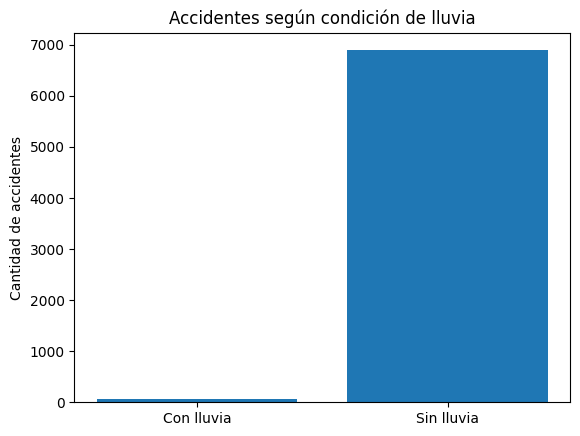

In [56]:
import matplotlib.pyplot as plt

categorias = ["Con lluvia", "Sin lluvia"]
valores = [66, 6889]

plt.bar(categorias, valores)
plt.title("Accidentes según condición de lluvia")
plt.ylabel("Cantidad de accidentes")
plt.show()

## Conclusión

En el análisis realizado se identificaron 6.955 accidentes que pudieron relacionarse con una medición de precipitación cercana. De estos, 66 ocurrieron durante condiciones con lluvia y 6.889 durante condiciones sin lluvia.

De manera preliminar, la tasa calculada fue menor en las mediciones con lluvia (11,56 accidentes por cada 100 mediciones) que en las mediciones sin lluvia (13,94), con una diferencia aproximada del 17,07%.

Estos resultados son descriptivos y no permiten afirmar que la lluvia reduzca los accidentes, ya que existen limitaciones en la cobertura temporal y en la disponibilidad de las mediciones de precipitación.